In [1]:
import math
import numpy as np
import scipy.optimize
from dataclasses import dataclass
from numpy.polynomial.legendre import leggauss

# -----------------------
# Physical constants
# -----------------------
F = 96485.33212       # C/mol
R = 8.314462618       # J/mol/K
eps0 = 8.8541878128e-12  # F/m


# ============================================================
# 1) Electrolyte: Debye length and nondimensionalization
# ============================================================

def debye_length_1to1(c_mol_L: float, T: float = 298.15, eps_r: float = 78.5) -> float:
    """
    Debye length for 1:1 electrolyte (Debye-Hückel / linearized PB):
        lambda_D = sqrt( eps * R T / (2 F^2 c) )
    where c is molar concentration in mol/m^3.
    """
    c = c_mol_L * 1000.0  # mol/L -> mol/m^3
    eps = eps_r * eps0
    return math.sqrt(eps * R * T / (2.0 * F**2 * c))


def to_dimless_potential(V: float, T: float) -> float:
    """Dimensionless potential: phi~ = F*V/(R*T)."""
    return F * V / (R * T)


def from_dimless_potential(phi_tilde: float, T: float) -> float:
    """Back to volts: V = (R*T/F)*phi~."""
    return (R * T / F) * phi_tilde


def g_tilde(Cdl_F_m2: float, lambda_D: float, eps_r: float = 78.5) -> float:
    """
    Dimensionless "capacitance strength" g~ used in your SI:
        g~ = (lambda_D/eps_s) * Cdl
    eps_s = eps_r * eps0.
    This matches the form g~ = (lambda_D/eps_s) C_dl in your derivation. :contentReference[oaicite:2]{index=2}
    """
    eps = eps_r * eps0
    return (lambda_D / eps) * Cdl_F_m2


# ============================================================
# 2) Galerkin solver for EDL (Debye-Hückel + Robin BC)
#    3 segments: Au | C | Pd
# ============================================================

def _J_cos(rho: float, a: float, b: float) -> float:
    """∫_a^b cos(rho x) dx"""
    if abs(rho) < 1e-14:
        return b - a
    return (math.sin(rho * b) - math.sin(rho * a)) / rho


def _I_coscos(rhom: float, rhon: float, a: float, b: float) -> float:
    """∫_a^b cos(rhom x) cos(rhon x) dx"""
    if abs(rhom) < 1e-14 and abs(rhon) < 1e-14:
        return b - a
    if abs(rhom - rhon) < 1e-14:
        if abs(rhom) < 1e-14:
            return b - a
        # ∫ cos^2 = 0.5(b-a) + [sin(2 rho x)]/(4 rho)
        return 0.5 * (b - a) + (math.sin(2 * rhom * b) - math.sin(2 * rhom * a)) / (4 * rhom)

    term1 = (math.sin((rhom - rhon) * b) - math.sin((rhom - rhon) * a)) / (rhom - rhon)
    term2 = (math.sin((rhom + rhon) * b) - math.sin((rhom + rhon) * a)) / (rhom + rhon)
    return 0.5 * (term1 + term2)


@dataclass
class PrecomputedEDL:
    """
    Store everything needed to evaluate:
      phi2(x; E) = a(x)*phiM + b(x)   (dimensionless)
    quickly for many E_mix calls.
    """
    # geometry in dimensionless x~ = x/lambda_D
    L_Au: float
    L_C: float
    L_Pd: float
    L_total: float
    x_bounds: tuple  # (0, L_Au, L_Au+L_C, L_total)

    # modal basis
    rho: np.ndarray
    gamma: np.ndarray

    # affine kernels for modal amplitudes:
    # A(phiM) = A_M * phiM - A_pzc
    A_M: np.ndarray
    A_pzc: np.ndarray

    # quadrature (for Au and Pd segments)
    xAu: np.ndarray
    wAu: np.ndarray
    xPd: np.ndarray
    wPd: np.ndarray

    # precomputed a(x), b(x) at quadrature nodes
    aAu: np.ndarray
    bAu: np.ndarray
    aPd: np.ndarray
    bPd: np.ndarray


def precompute_edl_3segment(
    # dimensionless lengths
    L_Au: float, L_C: float, L_Pd: float,
    # dimensionless g~ per segment
    gAu: float, gC: float, gPd: float,
    # dimensionless pzc potentials per segment
    pzcAu_tilde: float, pzcC_tilde: float, pzcPd_tilde: float,
    # numerics
    N_modes: int = 160,
    quad_pts: int = 600,
) -> PrecomputedEDL:
    """
    Build Galerkin matrix (diag(gamma)+S) and compute A_M, A_pzc so A = A_M*phiM - A_pzc.
    This is exactly the affine structure discussed in your SI (linear DH + linear Cdl). :contentReference[oaicite:3]{index=3}
    """
    L_total = L_Au + L_C + L_Pd
    x0 = 0.0
    x1 = L_Au
    x2 = L_Au + L_C
    x3 = L_total
    x_bounds = (x0, x1, x2, x3)

    segs = [
        (x0, x1, gAu, pzcAu_tilde),
        (x1, x2, gC,  pzcC_tilde),
        (x2, x3, gPd, pzcPd_tilde),
    ]

    # modal wavenumbers and decay constants
    rho = np.array([n * math.pi / L_total for n in range(N_modes + 1)], dtype=float)
    gamma = np.sqrt(1.0 + rho**2)

    # Build S matrix and r-vectors (rM and rpzc)
    S = np.zeros((N_modes + 1, N_modes + 1), dtype=float)
    rM = np.zeros(N_modes + 1, dtype=float)
    rpzc = np.zeros(N_modes + 1, dtype=float)

    # rM[m] = ∫ w_m g dx ; rpzc[m] = ∫ w_m g pzc dx
    for m in range(N_modes + 1):
        w_pref = (1.0 / L_total) if (m == 0) else (2.0 / L_total)
        for (a, b, g, pzc) in segs:
            Jm = _J_cos(rho[m], a, b)
            rM[m] += w_pref * g * Jm
            rpzc[m] += w_pref * g * pzc * Jm

    # S[m,n] = ∫ w_m g cos(rho_n x) dx
    for m in range(N_modes + 1):
        if m == 0:
            w_pref = 1.0 / L_total
            for n in range(N_modes + 1):
                val = 0.0
                for (a, b, g, pzc) in segs:
                    val += g * _J_cos(rho[n], a, b)
                S[m, n] = w_pref * val
        else:
            w_pref = 2.0 / L_total
            for n in range(N_modes + 1):
                val = 0.0
                for (a, b, g, pzc) in segs:
                    val += g * _I_coscos(rho[m], rho[n], a, b)
                S[m, n] = w_pref * val

    Mmat = np.diag(gamma) + S

    # Solve for affine kernels:
    # A_M = M^{-1} rM
    # A_pzc = M^{-1} rpzc
    A_M = np.linalg.solve(Mmat, rM)
    A_pzc = np.linalg.solve(Mmat, rpzc)

    # Gauss-Legendre quadrature nodes/weights on Au and Pd segments
    def _gauss_segment(a, b, npts):
        xg, wg = leggauss(npts)
        x = 0.5*(b+a) + 0.5*(b-a)*xg
        w = 0.5*(b-a)*wg
        return x, w

    xAu, wAu = _gauss_segment(x0, x1, quad_pts)
    xPd, wPd = _gauss_segment(x2, x3, quad_pts)

    # precompute a(x), b(x) at quadrature nodes:
    # phi2(x) = a(x)*phiM + b(x), with
    # a(x) = Σ A_M[n] cos(rho_n x)
    # b(x) = -Σ A_pzc[n] cos(rho_n x)
    def _a_b_on_grid(xgrid):
        cosmx = np.cos(np.outer(rho, xgrid))  # (N+1, ngrid)
        a = (A_M[:, None] * cosmx).sum(axis=0)
        b = (-A_pzc[:, None] * cosmx).sum(axis=0)
        return a, b

    aAu, bAu = _a_b_on_grid(xAu)
    aPd, bPd = _a_b_on_grid(xPd)

    return PrecomputedEDL(
        L_Au=L_Au, L_C=L_C, L_Pd=L_Pd, L_total=L_total, x_bounds=x_bounds,
        rho=rho, gamma=gamma,
        A_M=A_M, A_pzc=A_pzc,
        xAu=xAu, wAu=wAu, xPd=xPd, wPd=wPd,
        aAu=aAu, bAu=bAu, aPd=aPd, bPd=bPd
    )


# ============================================================
# 3) Mixed potential + K-factors + d ln i / d E
# ============================================================

@dataclass
class Kinetics:
    """
    Kinetic parameters for the two half-reactions (irreversible approximation used in SI S3).
    """
    T: float               # K
    alpha1: float          # anodic symmetry: (1-alpha1) appears for i1 in SI
    alpha2: float
    Eeq1: float            # V
    Eeq2: float            # V
    i01: float             # true exchange current density for half-reaction 1 (same units as i02)
    i02: float

    z_R1: int = 0          # charge number for reduced species in half-reaction 1
    z_O2: int = 0          # charge number for oxidized species in half-reaction 2


def K_factors(pre: PrecomputedEDL, kin: Kinetics, phiM: float):
    """
    K_Au(E) = (1/L_Au) ∫_Au exp( -rho_coef * phi2(x;E) ) dx
    K_Pd(E) = (1/L_Pd) ∫_Pd exp( +chi_coef * phi2(x;E) ) dx
    matching SI (S3-11)-(S3-12) when written with dimensionless phi2. :contentReference[oaicite:4]{index=4}
    """
    rho_coef = (1.0 - kin.alpha1) + kin.z_R1      # ρ
    chi_coef = kin.alpha2 - kin.z_O2              # χ

    # phi2(x)=a(x)*phiM + b(x)
    phiAu = pre.aAu * phiM + pre.bAu
    phiPd = pre.aPd * phiM + pre.bPd

    expAu = np.exp(-rho_coef * phiAu)
    expPd = np.exp(+chi_coef * phiPd)

    KAu = (expAu * pre.wAu).sum() / pre.L_Au
    KPd = (expPd * pre.wPd).sum() / pre.L_Pd

    # Derivatives wrt phiM:
    # dK/dphiM = ∫ exp(...) * (d/dphiM exponent) dx
    dKAu_dphiM = (expAu * (-rho_coef * pre.aAu) * pre.wAu).sum() / pre.L_Au
    dKPd_dphiM = (expPd * (+chi_coef * pre.aPd) * pre.wPd).sum() / pre.L_Pd

    dlnKAu_dphiM = dKAu_dphiM / KAu
    dlnKPd_dphiM = dKPd_dphiM / KPd

    # "weighted average" of a(x) that causes nonlinearity (your SI D5 discussion) :contentReference[oaicite:5]{index=5}
    aAu_w = (pre.aAu * expAu * pre.wAu).sum() / (expAu * pre.wAu).sum()
    aPd_w = (pre.aPd * expPd * pre.wPd).sum() / (expPd * pre.wPd).sum()

    return {
        "KAu": KAu, "KPd": KPd,
        "dlnKAu_dphiM": dlnKAu_dphiM,
        "dlnKPd_dphiM": dlnKPd_dphiM,
        "aAu_weighted": aAu_w,
        "aPd_weighted": aPd_w,
        "rho_coef": rho_coef,
        "chi_coef": chi_coef
    }


def solve_Emix(pre: PrecomputedEDL, kin: Kinetics, bracket_halfwidth_V: float = 0.6):
    """
    Solve mixed potential by net-current = 0:
        I1(E) + I2(E) = 0
    with
        I1 = i01 * exp((1-alpha1)*(phiM - phi_eq1)) * L_Au * KAu(E)
        I2 = -i02 * exp((-alpha2)*(phiM - phi_eq2)) * L_Pd * KPd(E)
    consistent with SI (S3-8)-(S3-10). :contentReference[oaicite:6]{index=6}
    """
    T = kin.T
    phi_eq1 = to_dimless_potential(kin.Eeq1, T)
    phi_eq2 = to_dimless_potential(kin.Eeq2, T)

    # base guess ignoring EDL (KAu=KPd=1)
    kappa = 1.0 - kin.alpha1 + kin.alpha2
    E0 = ((1.0 - kin.alpha1) * kin.Eeq1 + kin.alpha2 * kin.Eeq2) / kappa \
         + (R*T/(F*kappa)) * math.log((pre.L_Pd * kin.i02) / (pre.L_Au * kin.i01))
    phi0 = to_dimless_potential(E0, T)

    def residual(phiM):
        K = K_factors(pre, kin, phiM)
        I1 = kin.i01 * math.exp((1.0 - kin.alpha1) * (phiM - phi_eq1)) * (pre.L_Au * K["KAu"])
        I2 = -kin.i02 * math.exp((-kin.alpha2) * (phiM - phi_eq2)) * (pre.L_Pd * K["KPd"])
        return I1 + I2

    # bracket search
    half_phi = to_dimless_potential(bracket_halfwidth_V, T)
    lo, hi = phi0 - half_phi, phi0 + half_phi
    flo, fhi = residual(lo), residual(hi)

    expand = 1
    while flo * fhi > 0 and expand < 30:
        expand += 1
        lo, hi = phi0 - expand*half_phi, phi0 + expand*half_phi
        flo, fhi = residual(lo), residual(hi)

    if flo * fhi > 0:
        # fallback: secant
        sol = scipy.optimize.root_scalar(residual, x0=phi0, x1=phi0 + half_phi, method="secant")
    else:
        sol = scipy.optimize.root_scalar(residual, bracket=(lo, hi), method="brentq")

    if not sol.converged:
        raise RuntimeError("E_mix root finding failed to converge.")

    phi_mix = sol.root
    E_mix = from_dimless_potential(phi_mix, T)

    # currents + K + sensitivities
    K = K_factors(pre, kin, phi_mix)
    I1 = kin.i01 * math.exp((1.0 - kin.alpha1) * (phi_mix - phi_eq1)) * (pre.L_Au * K["KAu"])
    I2 = -kin.i02 * math.exp((-kin.alpha2) * (phi_mix - phi_eq2)) * (pre.L_Pd * K["KPd"])

    # log-derivatives w.r.t E (Volts)
    # ln I1 = const + (1-alpha1)*phiM + ln KAu(phiM)  => d ln I1/dE = (F/RT)*[(1-alpha1)+dlnK/dphiM]
    # ln |I2|= const + (-alpha2)*phiM + ln KPd(phiM) => d ln |I2|/dE = (F/RT)*[(-alpha2)+dlnK/dphiM]
    factor = F / (R * T)
    dlnI1_dE = factor * ((1.0 - kin.alpha1) + K["dlnKAu_dphiM"])
    dlnI2_dE = factor * ((-kin.alpha2) + K["dlnKPd_dphiM"])

    # "mean-field" constant-slope prediction (if a(x) ~ constant on each segment)
    # from your SI D5: dln i1/dE = (F/RT)[(1-a1) - rho*a1], etc. :contentReference[oaicite:7]{index=7}
    # Here we approximate a_mean by the unweighted average of a(x) over segment using quadrature:
    aAu_mean = (pre.aAu * pre.wAu).sum() / pre.L_Au
    aPd_mean = (pre.aPd * pre.wPd).sum() / pre.L_Pd
    rho_coef = K["rho_coef"]
    chi_coef = K["chi_coef"]
    dlnI1_dE_meanfield = factor * ((1.0 - kin.alpha1) - rho_coef * aAu_mean)
    dlnI2_dE_meanfield = factor * ((-kin.alpha2) + chi_coef * aPd_mean)

    return {
        "E_mix": E_mix,
        "phi_mix": phi_mix,
        "I1": I1,
        "I2": I2,
        "K": K,
        "dlnI1_dE": dlnI1_dE,
        "dlnI2_dE": dlnI2_dE,
        "aAu_mean": aAu_mean,
        "aPd_mean": aPd_mean,
        "dlnI1_dE_meanfield": dlnI1_dE_meanfield,
        "dlnI2_dE_meanfield": dlnI2_dE_meanfield,
    }


In [2]:
def build_problem_from_physical(
    # geometry (nm)
    L_Au_nm: float,
    L_C_nm: float,
    L_Pd_nm: float,
    # electrolyte
    c_mol_L: float,
    T: float = 298.15,
    eps_r: float = 78.5,
    # materials: pzc (V), Cdl (F/m^2)
    pzc_Au_V: float = 0.0,
    pzc_C_V: float  = 0.0,
    pzc_Pd_V: float = 0.0,
    Cdl_Au: float = 0.20,   # typical order 0.1~0.4 F/m^2
    Cdl_C: float  = 0.10,
    Cdl_Pd: float = 0.30,
    # numerics
    N_modes: int = 160,
    quad_pts: int = 600,
):
    # electrolyte scaling
    lamD = debye_length_1to1(c_mol_L=c_mol_L, T=T, eps_r=eps_r)

    # convert lengths to dimensionless x~ = x/lambda_D
    nm = 1e-9
    L_Au = (L_Au_nm * nm) / lamD
    L_C  = (L_C_nm  * nm) / lamD
    L_Pd = (L_Pd_nm * nm) / lamD

    # dimensionless g~
    gAu = g_tilde(Cdl_Au, lamD, eps_r)
    gC  = g_tilde(Cdl_C,  lamD, eps_r)
    gPd = g_tilde(Cdl_Pd, lamD, eps_r)

    # dimensionless pzc
    pzcAu_t = to_dimless_potential(pzc_Au_V, T)
    pzcC_t  = to_dimless_potential(pzc_C_V,  T)
    pzcPd_t = to_dimless_potential(pzc_Pd_V, T)

    pre = precompute_edl_3segment(
        L_Au=L_Au, L_C=L_C, L_Pd=L_Pd,
        gAu=gAu, gC=gC, gPd=gPd,
        pzcAu_tilde=pzcAu_t, pzcC_tilde=pzcC_t, pzcPd_tilde=pzcPd_t,
        N_modes=N_modes, quad_pts=quad_pts
    )
    return pre, lamD


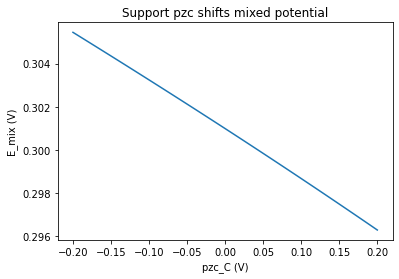

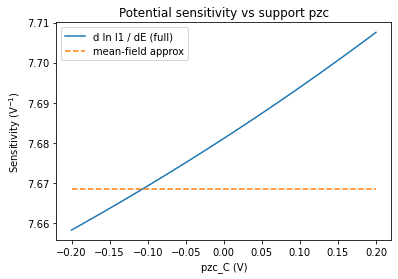

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---- fixed baseline ----
T = 298.15
eps_r = 78.5
c = 0.01   # 10 mM electrolyte

kin = Kinetics(
    T=T,
    alpha1=0.6, alpha2=0.4,
    Eeq1=0.20, Eeq2=0.00,
    i01=1e-6, i02=2e-6,
    z_R1=0, z_O2=0
)

# geometry (nm): interpret as particle sizes + separation
L_Au_nm, L_C_nm, L_Pd_nm = 10.0, 20.0, 20.0

# material params
pzc_Au_V = 0.10
pzc_Pd_V = -0.05
Cdl_Au, Cdl_C, Cdl_Pd = 0.25, 0.08, 0.35

pzcC_list = np.linspace(-0.2, 0.2, 61)

E_mix_list = []
sens1_list = []
sens2_list = []
sens1_mf_list = []

for pzc_C_V in pzcC_list:
    pre, lamD = build_problem_from_physical(
        L_Au_nm=L_Au_nm, L_C_nm=L_C_nm, L_Pd_nm=L_Pd_nm,
        c_mol_L=c, T=T, eps_r=eps_r,
        pzc_Au_V=pzc_Au_V, pzc_C_V=pzc_C_V, pzc_Pd_V=pzc_Pd_V,
        Cdl_Au=Cdl_Au, Cdl_C=Cdl_C, Cdl_Pd=Cdl_Pd,
        N_modes=160, quad_pts=600
    )
    out = solve_Emix(pre, kin)

    E_mix_list.append(out["E_mix"])
    sens1_list.append(out["dlnI1_dE"])
    sens2_list.append(out["dlnI2_dE"])
    sens1_mf_list.append(out["dlnI1_dE_meanfield"])

E_mix_list = np.array(E_mix_list)
sens1_list  = np.array(sens1_list)
sens2_list  = np.array(sens2_list)
sens1_mf_list = np.array(sens1_mf_list)

plt.figure()
plt.plot(pzcC_list, E_mix_list)
plt.xlabel("pzc_C (V)")
plt.ylabel("E_mix (V)")
plt.title("Support pzc shifts mixed potential")
plt.show()

plt.figure()
plt.plot(pzcC_list, sens1_list, label="d ln I1 / dE (full)")
plt.plot(pzcC_list, sens1_mf_list, "--", label="mean-field approx")
plt.xlabel("pzc_C (V)")
plt.ylabel("Sensitivity (V$^{-1}$)")
plt.legend()
plt.title("Potential sensitivity vs support pzc")
plt.show()


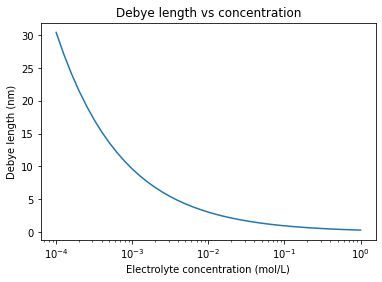

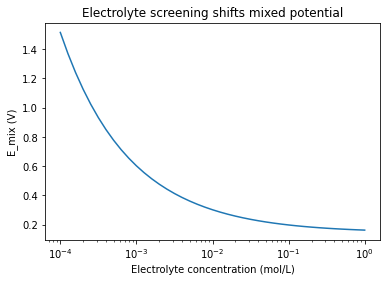

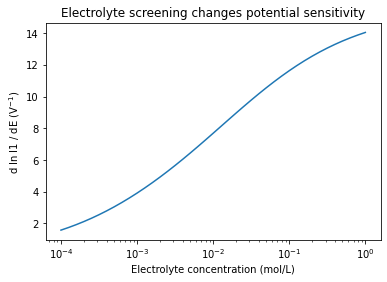

In [4]:
c_list = np.logspace(-4, 0, 41)  # 0.1 mM to 1 M

E_mix_list = []
lamD_list  = []
sens1_list = []

for c in c_list:
    pre, lamD = build_problem_from_physical(
        L_Au_nm=10.0, L_C_nm=20.0, L_Pd_nm=20.0,
        c_mol_L=float(c), T=T, eps_r=eps_r,
        pzc_Au_V=pzc_Au_V, pzc_C_V=0.0, pzc_Pd_V=pzc_Pd_V,
        Cdl_Au=Cdl_Au, Cdl_C=Cdl_C, Cdl_Pd=Cdl_Pd,
        N_modes=160, quad_pts=600
    )
    out = solve_Emix(pre, kin)

    lamD_list.append(lamD * 1e9)   # nm
    E_mix_list.append(out["E_mix"])
    sens1_list.append(out["dlnI1_dE"])

lamD_list  = np.array(lamD_list)
E_mix_list = np.array(E_mix_list)
sens1_list = np.array(sens1_list)

plt.figure()
plt.semilogx(c_list, lamD_list)
plt.xlabel("Electrolyte concentration (mol/L)")
plt.ylabel("Debye length (nm)")
plt.title("Debye length vs concentration")
plt.show()

plt.figure()
plt.semilogx(c_list, E_mix_list)
plt.xlabel("Electrolyte concentration (mol/L)")
plt.ylabel("E_mix (V)")
plt.title("Electrolyte screening shifts mixed potential")
plt.show()

plt.figure()
plt.semilogx(c_list, sens1_list)
plt.xlabel("Electrolyte concentration (mol/L)")
plt.ylabel("d ln I1 / dE (V$^{-1}$)")
plt.title("Electrolyte screening changes potential sensitivity")
plt.show()


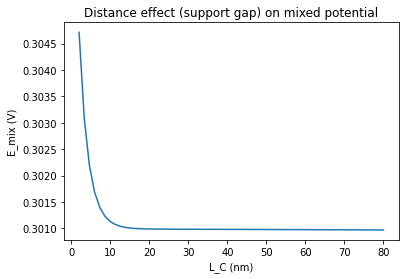

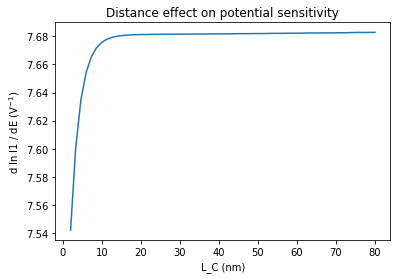

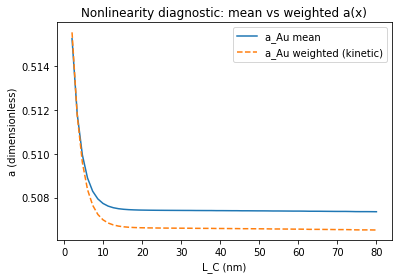

In [5]:
LC_list = np.linspace(2.0, 80.0, 60)  # nm

E_mix_list = []
sens1_list = []
aAu_mean_list = []
aAu_w_list = []

for LC_nm in LC_list:
    pre, lamD = build_problem_from_physical(
        L_Au_nm=10.0, L_C_nm=float(LC_nm), L_Pd_nm=20.0,
        c_mol_L=0.01, T=T, eps_r=eps_r,
        pzc_Au_V=pzc_Au_V, pzc_C_V=0.0, pzc_Pd_V=pzc_Pd_V,
        Cdl_Au=Cdl_Au, Cdl_C=Cdl_C, Cdl_Pd=Cdl_Pd,
        N_modes=160, quad_pts=600
    )
    out = solve_Emix(pre, kin)

    E_mix_list.append(out["E_mix"])
    sens1_list.append(out["dlnI1_dE"])
    aAu_mean_list.append(out["aAu_mean"])
    aAu_w_list.append(out["K"]["aAu_weighted"])

E_mix_list = np.array(E_mix_list)
sens1_list = np.array(sens1_list)
aAu_mean_list = np.array(aAu_mean_list)
aAu_w_list = np.array(aAu_w_list)

plt.figure()
plt.plot(LC_list, E_mix_list)
plt.xlabel("L_C (nm)")
plt.ylabel("E_mix (V)")
plt.title("Distance effect (support gap) on mixed potential")
plt.show()

plt.figure()
plt.plot(LC_list, sens1_list)
plt.xlabel("L_C (nm)")
plt.ylabel("d ln I1 / dE (V$^{-1}$)")
plt.title("Distance effect on potential sensitivity")
plt.show()

plt.figure()
plt.plot(LC_list, aAu_mean_list, label="a_Au mean")
plt.plot(LC_list, aAu_w_list, "--", label="a_Au weighted (kinetic)")
plt.xlabel("L_C (nm)")
plt.ylabel("a (dimensionless)")
plt.legend()
plt.title("Nonlinearity diagnostic: mean vs weighted a(x)")
plt.show()
